<a href="https://colab.research.google.com/github/BarryDeCicco/Machine-Learning-with-scikit-learn/blob/main/Exercise%20Files/02_07_decision_tree_modified.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 02_07 — Build a Decision Tree

In this notebook, you'll create and visualize a **Decision Tree** classifier using scikit-learn's `make_moons` dataset.  
Decision Trees are interpretable and let you see how models make decisions step by step.


**Example Decision Tree - Should you wear a rain jacket?**

```
              Is it raining?
                [Root node]
                 /       \
               Yes        No
                |          \
                |        [Leaf] Do not wear jacket
                |
         Is it cold outside?
            [interior node]
            /         \
          Yes         No
           |           \
   [Leaf] Wear rain    [Leaf] Take umbrella only
           jacket
```



## Import libraries

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn import metrics

## Generate the dataset

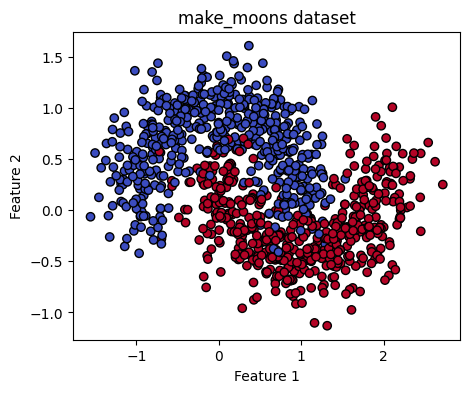

In [4]:

X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)

plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.coolwarm, edgecolor='k')
plt.title("make_moons dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [5]:
# create a train/test split in your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

#### Explore the data sets:

In [8]:
print(type(X_train))
print(type(X_test))
print(type(y_train))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [9]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(700, 2)
(300, 2)
(700,)
(300,)


## Train a Decision Tree model

In [20]:
tree = DecisionTreeClassifier(max_depth=3, random_state=1)
tree.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=1)

## Visualize the Decision Tree structure

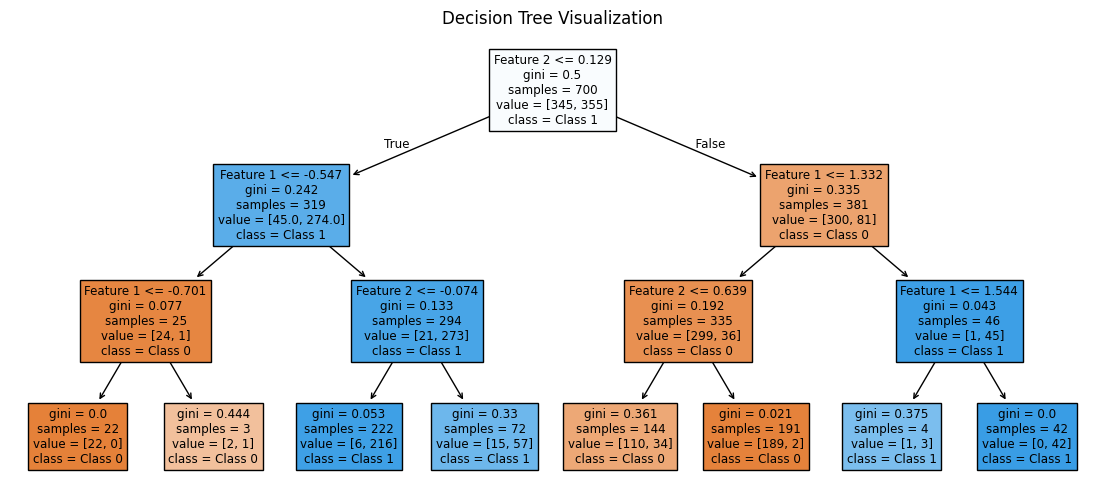

In [21]:
plt.figure(figsize=(14,6))
plot_tree(tree, filled=True, feature_names=['Feature 1', 'Feature 2'], class_names=['Class 0', 'Class 1'])
plt.title("Decision Tree Visualization")
plt.show()


## Split, fit, predict

In [22]:
# predict on the test set
y_pred = tree.predict(X_test)
y_prob = tree.predict_proba(X_test)[:, 1]

acc  = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy:  {acc:.3f}")

Accuracy:  0.897


## Confusion matrix

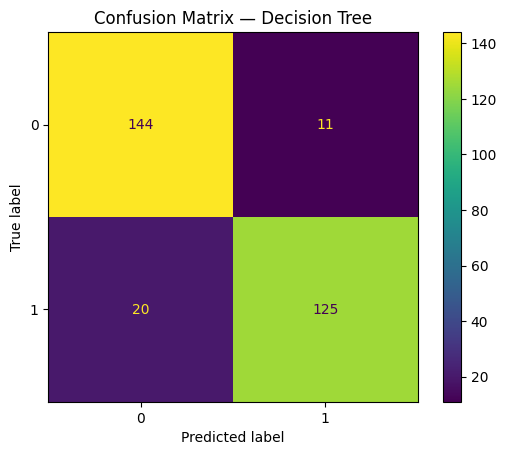

In [23]:

cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(values_format='d')
plt.title("Confusion Matrix — Decision Tree")
plt.show()

## Accuracy, Precision, and Recall

In [24]:

prec = metrics.precision_score(y_test, y_pred, zero_division=0)
rec  = metrics.recall_score(y_test, y_pred)
f1   = metrics.f1_score(y_test, y_pred)

print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 score:  {f1:.3f}")

Precision: 0.919
Recall:    0.862
F1 score:  0.890


## ROC curve

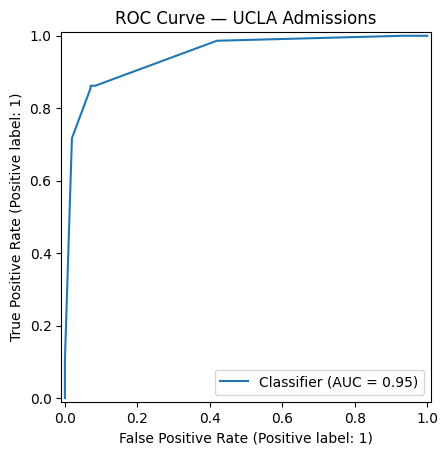

In [26]:

metrics.RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve — UCLA Admissions")
plt.show()

## ROC AUC (Area under the Curve)

In [25]:
auc  = metrics.roc_auc_score(y_test, y_prob)
print(f"AUC:       {auc:.3f}")

AUC:       0.947
